In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

subset   = pd.read_csv('../data/subset.csv')
calendar = pd.read_csv('../data/calendar.csv')
prices   = pd.read_csv('../data/sell_prices.csv')

day_cols = [c for c in subset.columns if c.startswith('d_')]
print("Loaded. Subset shape:", subset.shape)

Loaded. Subset shape: (200, 1947)


In [2]:
# Right now each row = 1 item, with 1941 columns for each dayS
# We need each row = 1 item on 1 day
# This is called melting — going from wide to long format

df = subset.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

print("Long format shape:", df.shape)
print("\nSample:")
df.head(5)

Long format shape: (388200, 8)

Sample:


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_348_CA_1_evaluation,HOBBIES_1_348,HOBBIES_1,HOBBIES,CA_1,CA,d_1,9
1,HOBBIES_1_371_CA_1_evaluation,HOBBIES_1_371,HOBBIES_1,HOBBIES,CA_1,CA,d_1,14
2,HOUSEHOLD_1_118_CA_1_evaluation,HOUSEHOLD_1_118,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,3
3,HOUSEHOLD_1_334_CA_1_evaluation,HOUSEHOLD_1_334,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,0
4,FOODS_1_218_CA_1_evaluation,FOODS_1_218,FOODS_1,FOODS,CA_1,CA,d_1,10


In [3]:
# Calendar has real dates for each d_ column
# Also has SNAP flags and event names

df = df.merge(calendar[['d', 'date', 'wday', 'month', 'year',
                          'event_name_1', 'event_type_1',
                          'snap_CA']], on='d', how='left')

df['date'] = pd.to_datetime(df['date'])

print("After calendar merge:", df.shape)
df.head(3)

After calendar merge: (388200, 15)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,month,year,event_name_1,event_type_1,snap_CA
0,HOBBIES_1_348_CA_1_evaluation,HOBBIES_1_348,HOBBIES_1,HOBBIES,CA_1,CA,d_1,9,2011-01-29,1,1,2011,NaN,NaN,0
1,HOBBIES_1_371_CA_1_evaluation,HOBBIES_1_371,HOBBIES_1,HOBBIES,CA_1,CA,d_1,14,2011-01-29,1,1,2011,NaN,NaN,0
2,HOUSEHOLD_1_118_CA_1_evaluation,HOUSEHOLD_1_118,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,3,2011-01-29,1,1,2011,NaN,NaN,0


In [4]:
# Prices change weekly — each item has a price per store per week
# We need wm_yr_wk from calendar for this merge

df = df.merge(
    calendar[['d', 'wm_yr_wk']],
    on='d', how='left'
)

df = df.merge(
    prices,
    on=['store_id', 'item_id', 'wm_yr_wk'],
    how='left'
)

print("After price merge:", df.shape)
print("Missing prices:", df['sell_price'].isnull().sum())
df.head(3)

After price merge: (388200, 17)
Missing prices: 24241


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wday,month,year,event_name_1,event_type_1,snap_CA,wm_yr_wk,sell_price
0,HOBBIES_1_348_CA_1_evaluation,HOBBIES_1_348,HOBBIES_1,HOBBIES,CA_1,CA,d_1,9,2011-01-29,1,1,2011,NaN,NaN,0,11101,0.46
1,HOBBIES_1_371_CA_1_evaluation,HOBBIES_1_371,HOBBIES_1,HOBBIES,CA_1,CA,d_1,14,2011-01-29,1,1,2011,NaN,NaN,0,11101,0.46
2,HOUSEHOLD_1_118_CA_1_evaluation,HOUSEHOLD_1_118,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,3,2011-01-29,1,1,2011,NaN,NaN,0,11101,0.97


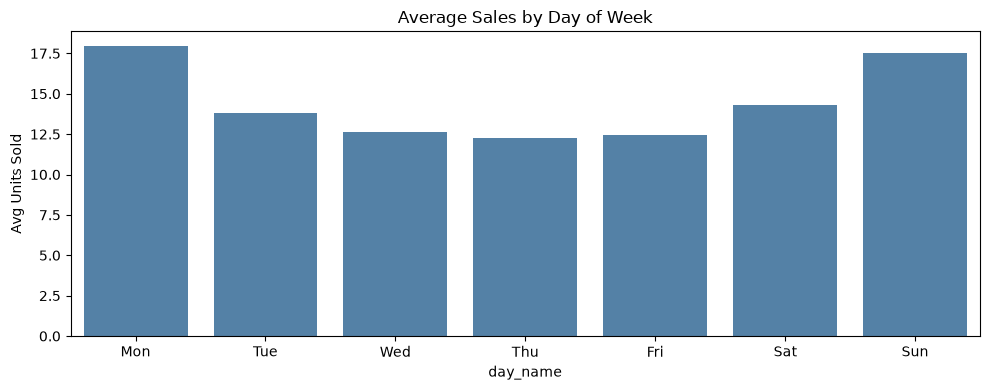

In [5]:
day_names = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
df['day_name'] = df['wday'].map(day_names)

avg_by_day = df.groupby('wday')['sales'].mean().reset_index()
avg_by_day['day_name'] = avg_by_day['wday'].map(day_names)

plt.figure(figsize=(10, 4))
sns.barplot(data=avg_by_day, x='day_name', y='sales',
            order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
            color='steelblue')
plt.title("Average Sales by Day of Week")
plt.ylabel("Avg Units Sold")
plt.tight_layout()
plt.savefig('../notebooks/eda_day_of_week.png')
plt.show()

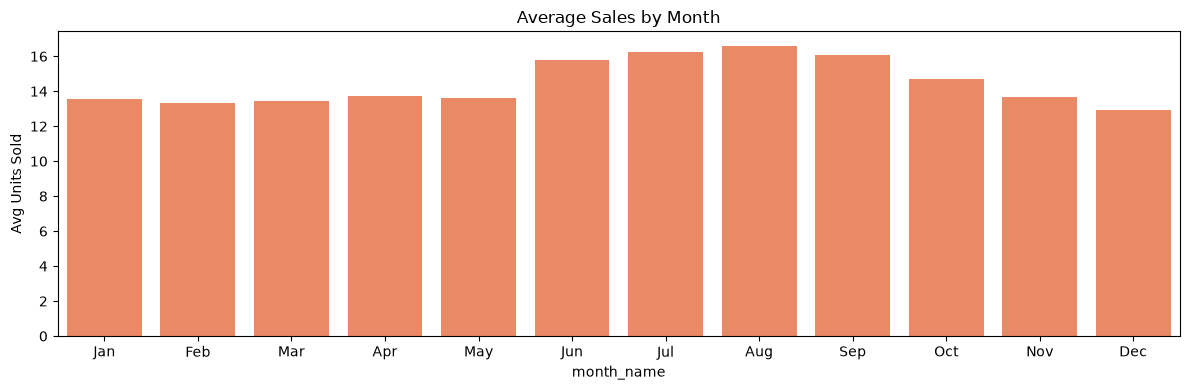

In [6]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

avg_by_month = df.groupby('month')['sales'].mean().reset_index()
avg_by_month['month_name'] = avg_by_month['month'].map(month_names)

plt.figure(figsize=(12, 4))
sns.barplot(data=avg_by_month, x='month_name', y='sales',
            order=list(month_names.values()), color='coral')
plt.title("Average Sales by Month")
plt.ylabel("Avg Units Sold")
plt.tight_layout()
plt.savefig('../notebooks/eda_by_month.png')
plt.show()

Average sales on non-SNAP days: 13.98
Average sales on SNAP days: 15.33
SNAP uplift: 9.7%


C:\Users\Aadya Kapoor\AppData\Local\Temp\ipykernel_21228\2105426953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-SNAP Day', 'SNAP Day'],


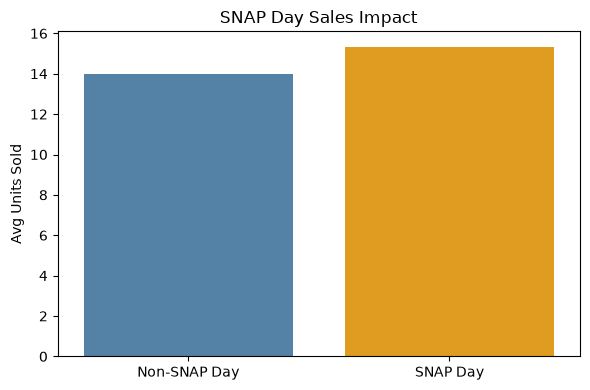

In [7]:
snap_avg = df.groupby('snap_CA')['sales'].mean()
print("Average sales on non-SNAP days:", snap_avg[0].round(2))
print("Average sales on SNAP days:", snap_avg[1].round(2))
print(f"SNAP uplift: {((snap_avg[1]/snap_avg[0])-1)*100:.1f}%")

plt.figure(figsize=(6, 4))
sns.barplot(x=['Non-SNAP Day', 'SNAP Day'],
            y=[snap_avg[0], snap_avg[1]],
            palette=['steelblue', 'orange'])
plt.title("SNAP Day Sales Impact")
plt.ylabel("Avg Units Sold")
plt.tight_layout()
plt.savefig('../notebooks/eda_snap_impact.png')
plt.show()

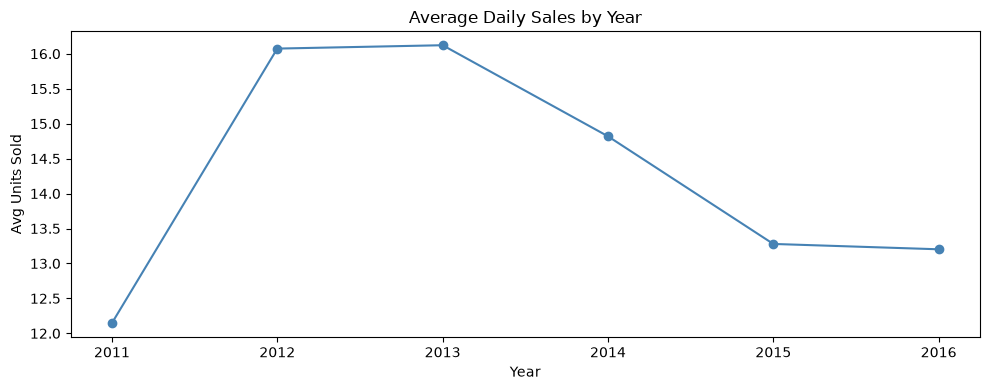

In [8]:
yearly = df.groupby('year')['sales'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(yearly['year'], yearly['sales'], marker='o', color='steelblue')
plt.title("Average Daily Sales by Year")
plt.ylabel("Avg Units Sold")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig('../notebooks/eda_yearly_trend.png')
plt.show()

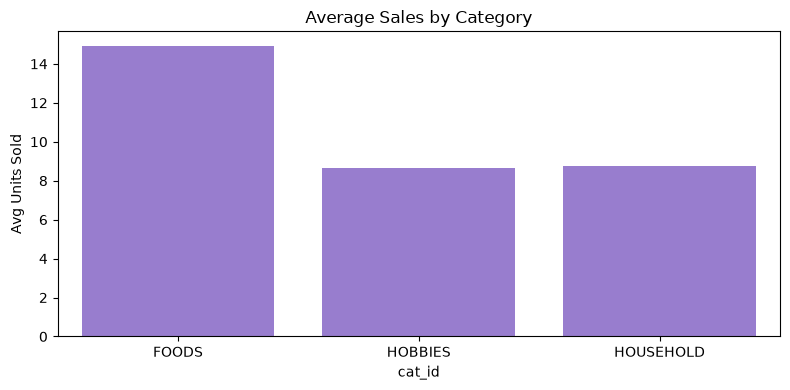

In [9]:
cat_avg = df.groupby('cat_id')['sales'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=cat_avg, x='cat_id', y='sales', color='mediumpurple')
plt.title("Average Sales by Category")
plt.ylabel("Avg Units Sold")
plt.tight_layout()
plt.show()

C:\Users\Aadya Kapoor\AppData\Local\Temp\ipykernel_21228\1780485125.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  zero_pct = df.groupby('item_id').apply(


Items with most zero-sale days:
    item_id  zero_pct
FOODS_3_362 51.622875
FOODS_3_282 49.497682
FOODS_3_499 46.831530
FOODS_3_120 46.342092
FOODS_3_288 45.929933
FOODS_3_739 44.848016
FOODS_3_281 33.784132
FOODS_3_711 33.114374
FOODS_3_607 32.341577
FOODS_3_752 32.083977


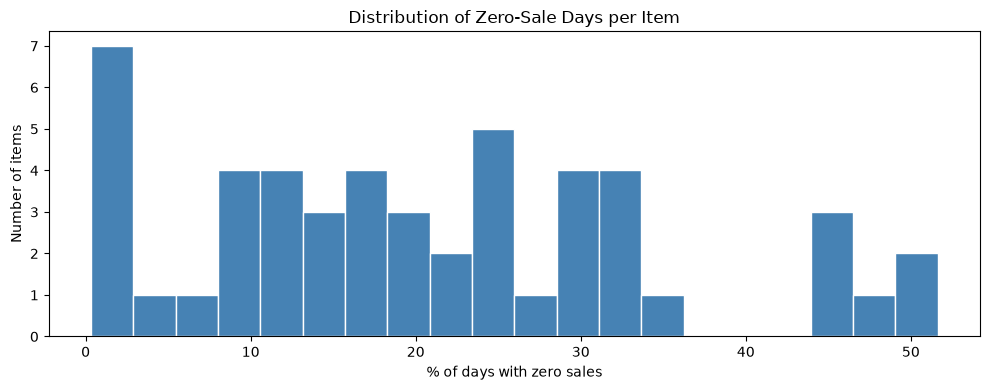

In [10]:
zero_pct = df.groupby('item_id').apply(
    lambda x: (x['sales'] == 0).mean() * 100
).reset_index()
zero_pct.columns = ['item_id', 'zero_pct']
zero_pct = zero_pct.sort_values('zero_pct', ascending=False)

print("Items with most zero-sale days:")
print(zero_pct.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.hist(zero_pct['zero_pct'], bins=20, color='steelblue', edgecolor='white')
plt.title("Distribution of Zero-Sale Days per Item")
plt.xlabel("% of days with zero sales")
plt.ylabel("Number of items")
plt.tight_layout()
plt.show()

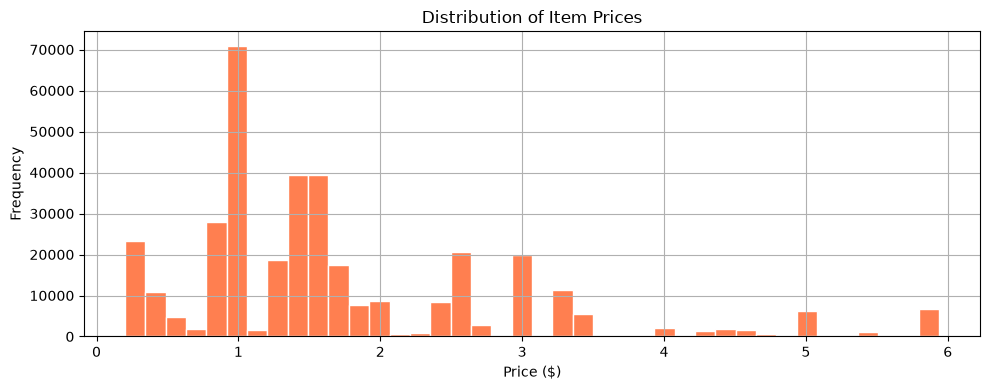

Price stats:
count    363959.00
mean          1.70
std           1.17
min           0.20
25%           0.98
50%           1.48
75%           2.24
max           5.94
Name: sell_price, dtype: float64


In [11]:
plt.figure(figsize=(10, 4))
df['sell_price'].dropna().hist(bins=40, color='coral', edgecolor='white')
plt.title("Distribution of Item Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Price stats:")
print(df['sell_price'].describe().round(2))

In [12]:
# This cell is just markdown — double click it to edit
# Write 5 observations from what you saw

observations = """
EDA Observations:
1. Sales peak on [day] — weekday/weekend pattern is strong
2. [Month] shows highest average sales — seasonal effect
3. SNAP days show X% uplift — significant feature for model
4. X% of item-days have zero sales — sparse demand challenge
5. Price range is $X to $Y — price elasticity worth capturing
"""
print(observations)


EDA Observations:
1. Sales peak on [day] — weekday/weekend pattern is strong
2. [Month] shows highest average sales — seasonal effect
3. SNAP days show X% uplift — significant feature for model
4. X% of item-days have zero sales — sparse demand challenge
5. Price range is $X to $Y — price elasticity worth capturing

